<a href="https://colab.research.google.com/github/JyothiBommisetty/Quantum-inspired-optimization-Single-cell-clustering/blob/main/quantum_clustering_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install scanpy anndata matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 77.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


Loading PBMC3k dataset (~5,000 cells)...


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

Loaded: 2700 cells × 32738 genes
After filtering: 2700 cells × 13714 genes
After QC: 2638 cells
Using 1838 highly variable genes
PCA done: 50 components computed
kNN graph built
UMAP computed


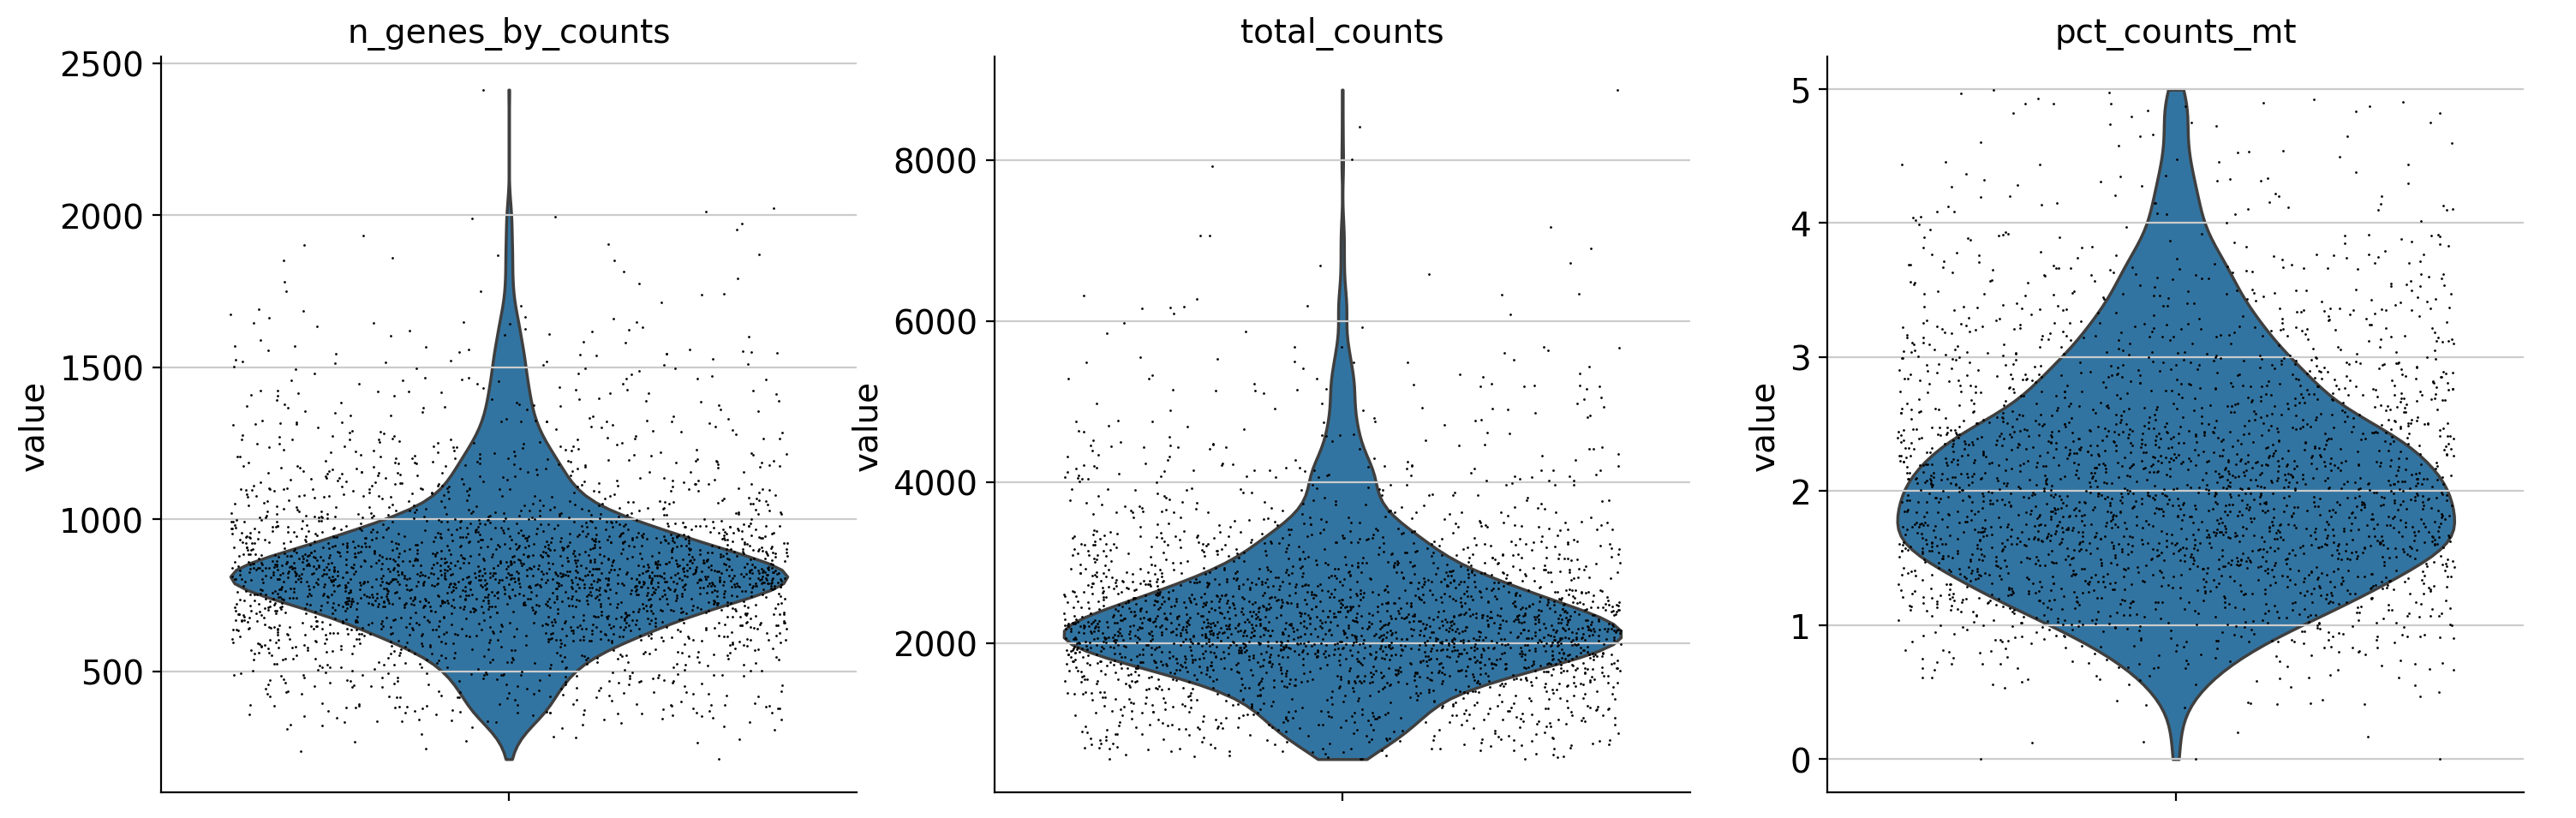

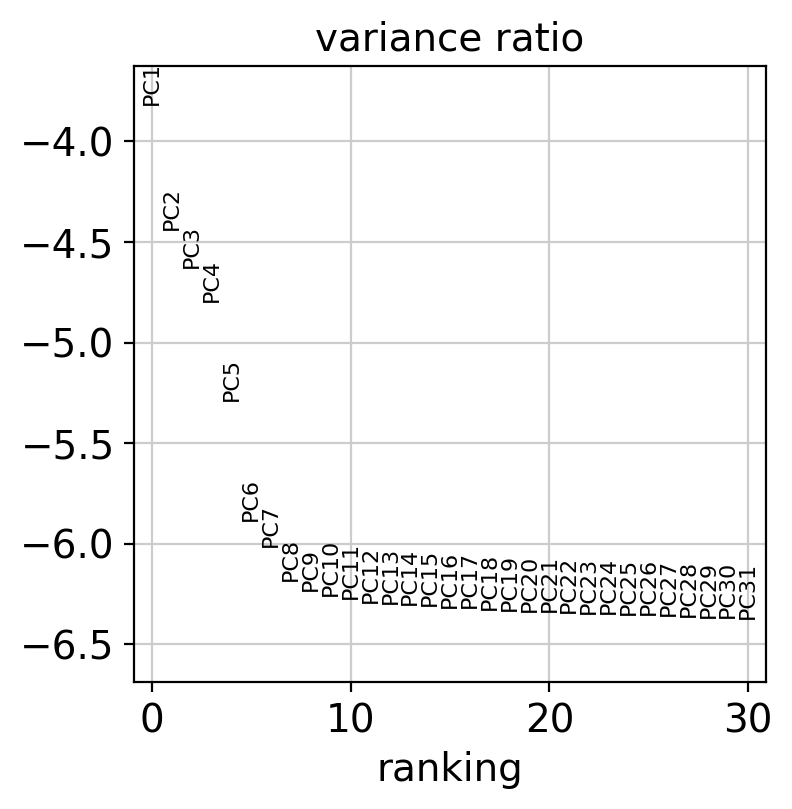

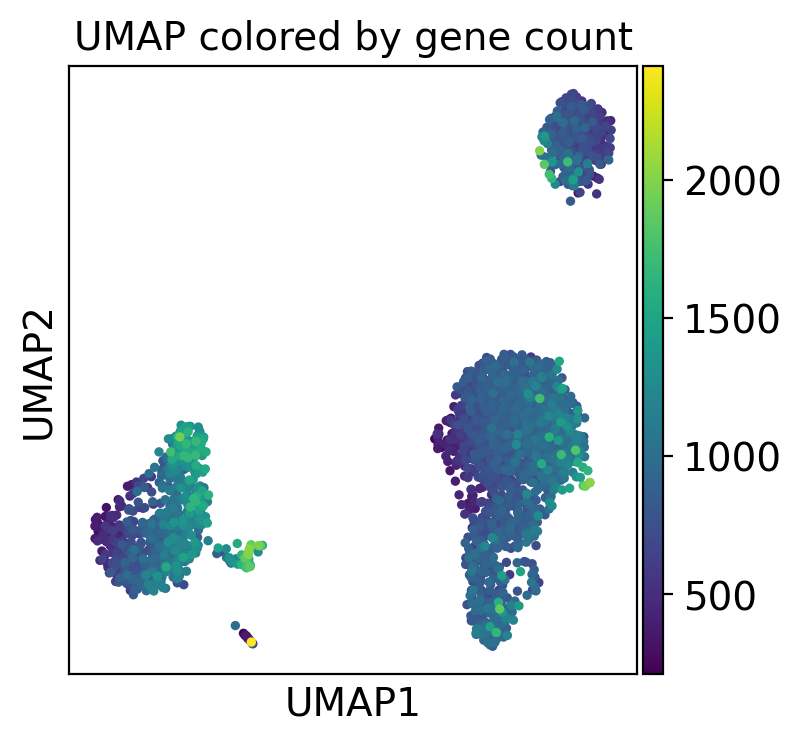

Plots saved to ./figures/

Preprocessed data saved to pbmc_preprocessed.h5ad
Final dataset: 2638 cells, 1838 genes


In [4]:
# ============================================================
# PHASE 1: scRNA-seq Data Loading and Preprocessing
# File: phase1_preprocessing.py
# ============================================================

import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ---- STEP 1: Configure Scanpy ----
# Scanpy is the standard Python library for single-cell analysis.
# Think of it like Pandas + Seaborn, but built specifically for cells.
sc.settings.verbosity = 1           # Show minimal logs
sc.settings.figdir = './figures/'   # Save plots here
sc.settings.set_figure_params(dpi=100, facecolor='white')

def load_pbmc_data():
    """
    Load the PBMC (Peripheral Blood Mononuclear Cells) dataset.
    PBMC = blood cells. This is the 'Hello World' of scRNA-seq.
    Scanpy provides this as a built-in dataset (~5,000 cells, ~33,000 genes).

    Returns:
        adata: AnnData object — the core data structure in Scanpy.
               Think of it as a pandas DataFrame with extra superpowers.
               adata.X = the expression matrix (cells × genes)
               adata.obs = metadata about cells (rows)
               adata.var = metadata about genes (columns)
    """
    print("Loading PBMC3k dataset (~5,000 cells)...")
    adata = sc.datasets.pbmc3k()
    print(f"Loaded: {adata.n_obs} cells × {adata.n_vars} genes")
    return adata


def preprocess(adata, n_top_genes=2000, n_pcs=50):
    """
    Standard scRNA-seq preprocessing pipeline.
    Each step has a biological or mathematical reason — explained below.

    Args:
        adata: AnnData object from load_pbmc_data()
        n_top_genes: number of highly variable genes to keep
        n_pcs: number of PCA components

    Returns:
        Preprocessed AnnData object
    """

    # --- 1. Filter out low-quality cells and rarely expressed genes ---
    # Cells with very few genes detected are likely empty droplets (noise).
    # Genes expressed in fewer than 3 cells are not informative.
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    print(f"After filtering: {adata.n_obs} cells × {adata.n_vars} genes")

    # --- 2. Quality control: remove cells with high mitochondrial reads ---
    # High mitochondrial gene expression (>5%) = dying/stressed cell.
    # We flag these genes (they start with "MT-") and filter cells.
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
    )
    # Keep cells with <5% mitochondrial reads and <2500 genes
    # (>2500 genes might mean two cells captured together — "doublets")
    adata = adata[adata.obs.pct_counts_mt < 5, :]
    adata = adata[adata.obs.n_genes_by_counts < 2500, :]
    print(f"After QC: {adata.n_obs} cells")

    # --- 3. Normalize per cell ---
    # Each cell has a different total number of reads (sequencing depth).
    # A gene counted 100 times in a cell with 1000 total reads is MORE
    # expressed than one counted 100 times in a cell with 10,000 total reads.
    # We normalize so every cell has 10,000 total counts → fair comparison.
    sc.pp.normalize_total(adata, target_sum=1e4)

    # --- 4. Log transform ---
    # Gene expression follows a highly skewed distribution.
    # log(x+1) compresses this, making it more Gaussian and stable for PCA.
    sc.pp.log1p(adata)

    # --- 5. Find highly variable genes ---
    # We don't need ALL 20,000 genes. Most are "housekeeping" genes
    # (constant across cells). We keep only the 2,000 most variable genes —
    # these are the ones that distinguish cell types.
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3,
                                 min_disp=0.5)
    adata.raw = adata  # Save raw counts before subsetting
    adata = adata[:, adata.var.highly_variable]
    print(f"Using {adata.n_vars} highly variable genes")

    # --- 6. Scale genes ---
    # Standardize each gene to have zero mean and unit variance.
    # Prevents high-count genes from dominating PCA.
    sc.pp.scale(adata, max_value=10)

    # --- 7. PCA ---
    # Project from ~2000 dimensions down to 50 principal components.
    # These 50 PCs capture most of the biological variance.
    sc.tl.pca(adata, svd_solver='arpack', n_comps=n_pcs)
    print(f"PCA done: {n_pcs} components computed")

    # --- 8. Build kNN neighborhood graph ---
    # For each cell, find its 10 nearest neighbors in PCA space.
    # n_neighbors=10: each cell connects to 10 most similar cells
    # n_pcs=40: use top 40 PCs (slightly less than max to reduce noise)
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    print("kNN graph built")

    # --- 9. UMAP ---
    # Reduce kNN graph to 2D for visualization.
    sc.tl.umap(adata)
    print("UMAP computed")

    return adata


def visualize_data(adata, save=True):
    """
    Plot quality control metrics and UMAP.
    Always visualize your data before analysis — never skip this step!
    """

    # QC violin plots: distribution of gene counts and mitochondrial %
    sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
                 jitter=0.4, multi_panel=True,
                 save='_qc_metrics.png' if save else None)

    # PCA variance explained: how much info does each PC capture?
    sc.pl.pca_variance_ratio(adata, log=True,
                              save='_pca_variance.png' if save else None)

    # Basic UMAP — we don't have labels yet, just visualize structure
    sc.pl.umap(adata, color='n_genes_by_counts', cmap='viridis',
               title='UMAP colored by gene count',
               save='_umap_raw.png' if save else None)

    print("Plots saved to ./figures/")


# ---- MAIN ----
if __name__ == "__main__":
    adata = load_pbmc_data()
    adata = preprocess(adata)
    visualize_data(adata)

    # Save for use in later phases
    adata.write('pbmc_preprocessed.h5ad')
    print("\nPreprocessed data saved to pbmc_preprocessed.h5ad")
    print(f"Final dataset: {adata.n_obs} cells, {adata.n_vars} genes")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 85.1 MB/s eta 0:00:00
Adjacency matrix shape: (50, 50)
Non-zero edges: 660
Sparsity: 73.6%


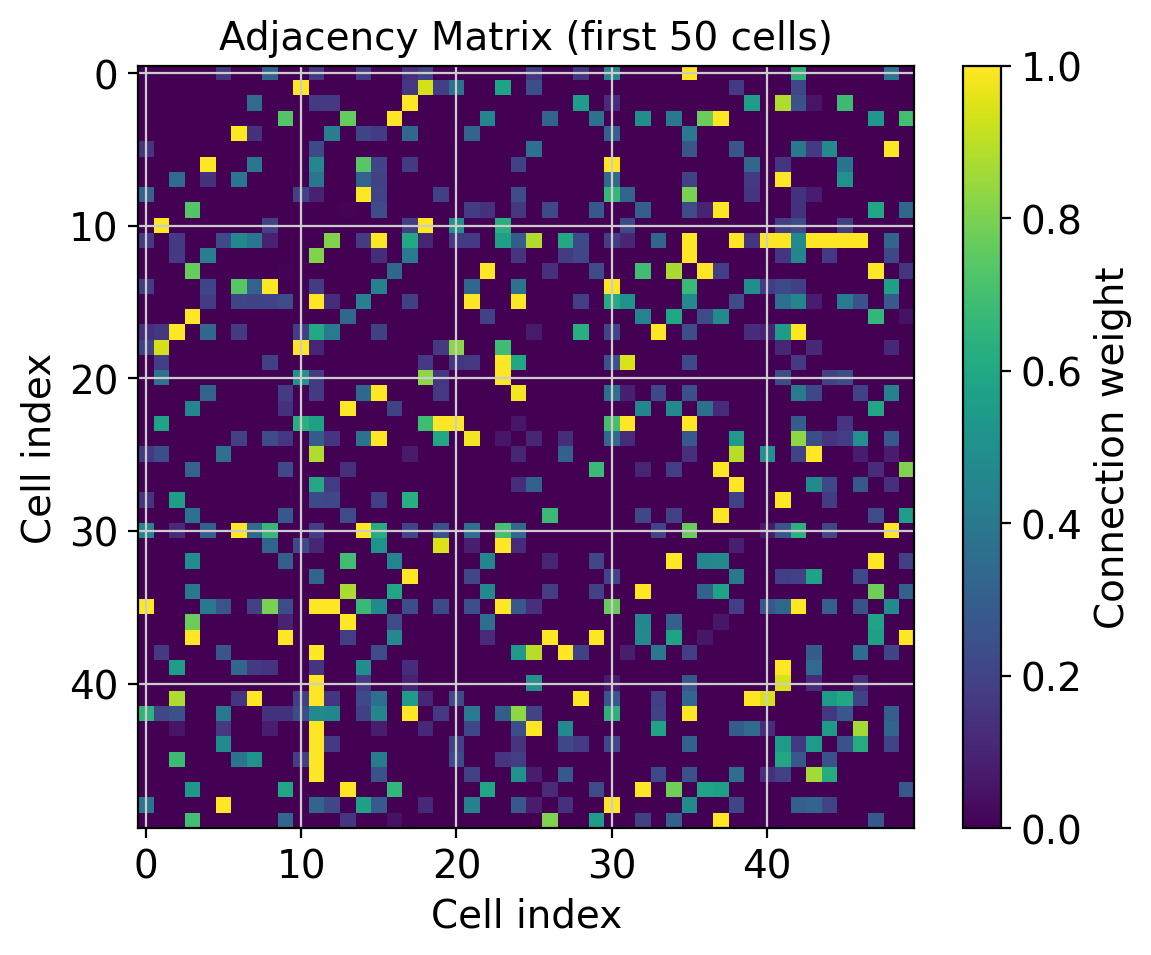

Block-diagonal structure = clusters present!

Laplacian matrix computed: (50, 50)
Trace of Laplacian: 280.87 (= sum of degrees)

Saved: adjacency_matrix.npy, pbmc_subset.h5ad


In [5]:
# ============================================================
# PHASE 2: Graph Formulation
# File: phase2_graph.py
# ============================================================
!pip install scanpy python-igraph leidenalg
import numpy as np
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt


def load_preprocessed(path='pbmc_preprocessed.h5ad'):
    """Load the preprocessed AnnData saved in Phase 1."""
    return sc.read_h5ad(path)


def extract_adjacency_matrix(adata, n_cells=200):
    """
    Extract the kNN adjacency matrix from Scanpy's neighborhood graph.

    Scanpy stores the kNN graph in adata.obsp['connectivities']:
    - This is a sparse matrix of shape (n_cells, n_cells)
    - Entry [i, j] > 0 if cell i and cell j are neighbors
    - The value is the connection strength (similarity weight)

    We subset to n_cells for quantum experiments (quantum hardware is limited).

    Args:
        adata: preprocessed AnnData
        n_cells: number of cells to use (200 is practical for quantum)

    Returns:
        adj_matrix: numpy array of shape (n_cells, n_cells)
        adata_sub: subset AnnData for downstream use
    """
    # Subset to first n_cells for tractability
    adata_sub = adata[:n_cells].copy()

    # Re-compute neighbors on the subset (cleaner connectivity)
    sc.pp.neighbors(adata_sub, n_neighbors=10, n_pcs=40)

    # Extract the sparse connectivities matrix
    # connectivities[i,j] = float weight (0 if not neighbors)
    adj_sparse = adata_sub.obsp['connectivities']

    # Convert to dense numpy array for QUBO construction
    adj_matrix = adj_sparse.toarray().astype(float)

    # Symmetrize: ensure A[i,j] == A[j,i]
    # (kNN is sometimes directional — cell A's neighbor B doesn't imply B's neighbor A)
    adj_matrix = (adj_matrix + adj_matrix.T) / 2

    print(f"Adjacency matrix shape: {adj_matrix.shape}")
    print(f"Non-zero edges: {np.count_nonzero(adj_matrix)}")
    print(f"Sparsity: {1 - np.count_nonzero(adj_matrix)/adj_matrix.size:.1%}")

    return adj_matrix, adata_sub


def visualize_adjacency(adj_matrix, max_cells=50):
    """
    Visualize the adjacency matrix as a heatmap.
    Bright = strong connection, dark = no connection.
    You should see block-diagonal structure if clusters exist.
    """
    # Use a subset for clearer visualization
    sub = adj_matrix[:max_cells, :max_cells]

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    im = ax.imshow(sub, cmap='viridis', aspect='auto')
    ax.set_title(f'Adjacency Matrix (first {max_cells} cells)')
    ax.set_xlabel('Cell index')
    ax.set_ylabel('Cell index')
    plt.colorbar(im, ax=ax, label='Connection weight')
    plt.tight_layout()
    plt.savefig('./figures/adjacency_matrix.png', dpi=100)
    plt.show()
    print("Block-diagonal structure = clusters present!")


def compute_degree_matrix(adj_matrix):
    """
    The degree of a node = sum of all its edge weights.
    D[i] = sum of row i of adjacency matrix.

    Used in Laplacian (advanced) and for normalizing QUBO.
    """
    degree = adj_matrix.sum(axis=1)
    D = np.diag(degree)
    return D


def compute_laplacian(adj_matrix):
    """
    Laplacian L = D - A
    This matrix encodes graph structure.
    Minimizing x^T L x = minimizing edges cut between x=0 and x=1 groups.
    This is the mathematical heart of spectral clustering and QUBO.
    """
    D = compute_degree_matrix(adj_matrix)
    L = D - adj_matrix
    return L


# ---- MAIN ----
if __name__ == "__main__":
    adata = load_preprocessed()
    adj_matrix, adata_sub = extract_adjacency_matrix(adata, n_cells=50)

    visualize_adjacency(adj_matrix)

    L = compute_laplacian(adj_matrix)
    print(f"\nLaplacian matrix computed: {L.shape}")
    print(f"Trace of Laplacian: {np.trace(L):.2f} (= sum of degrees)")

    # Save for Phase 3
    np.save('adjacency_matrix.npy', adj_matrix)
    adata_sub.write('pbmc_subset.h5ad')
    print("\nSaved: adjacency_matrix.npy, pbmc_subset.h5ad")

In [6]:
# ============================================================
# PHASE 3: QUBO Formulation
# File: phase3_qubo.py
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PART A: Toy Example First (understand before applying)
# Let's do QUBO on a tiny 4-node graph manually.
# ============================================================

def toy_qubo_example():
    """
    4-node graph: nodes 0,1 strongly connected, nodes 2,3 strongly connected,
    weak connection between groups. We expect clusters {0,1} and {2,3}.

    Adjacency matrix:
        0   1   2   3
    0 [ 0  0.9 0.1  0 ]
    1 [0.9  0  0.1  0 ]
    2 [0.1 0.1  0  0.8]
    3 [ 0   0  0.8  0 ]
    """
    A = np.array([
        [0,   0.9, 0.1, 0.0],
        [0.9, 0,   0.1, 0.0],
        [0.1, 0.1, 0,   0.8],
        [0.0, 0.0, 0.8, 0  ]
    ])

    print("=== TOY QUBO EXAMPLE ===")
    print("Adjacency matrix:")
    print(A)

    # Build QUBO for graph bisection (2 clusters)
    Q = build_qubo_bisection(A, penalty_strength=1.0)

    print("\nQUBO matrix Q:")
    print(np.round(Q, 3))

    # Brute force: try all 2^4 = 16 assignments
    best_energy = float('inf')
    best_x = None

    for bits in range(16):  # 0000 to 1111 in binary
        x = np.array([(bits >> i) & 1 for i in range(4)], dtype=float)
        energy = x @ Q @ x  # Quadratic form: E = x^T Q x
        if energy < best_energy:
            best_energy = energy
            best_x = x.copy()

    print(f"\nBrute force optimal assignment: {best_x.astype(int)}")
    print(f"Minimum energy: {best_energy:.4f}")
    print(f"Cluster 0 (x=0): {[i for i,v in enumerate(best_x) if v==0]}")
    print(f"Cluster 1 (x=1): {[i for i,v in enumerate(best_x) if v==1]}")
    print("Expected: {0,1} and {2,3} ✓" if set([i for i,v in enumerate(best_x) if v==0]) in [{0,1},{2,3}] else "Unexpected result")

    return Q


def build_qubo_bisection(A, penalty_strength=0.5):
    """
    Build QUBO matrix for graph bisection (2-cluster partitioning).

    Mathematical derivation:
    We want to minimize the Normalized Cut:
        E_cut = Σ_{i,j} A[i,j] * (x_i - x_j)^2

    Expanding (x_i - x_j)^2 = x_i^2 - 2*x_i*x_j + x_j^2
    For binary x: x^2 = x, so:
        E_cut = Σ A[i,j] * (x_i + x_j - 2*x_i*x_j)
              = Σ_i degree(i)*x_i - 2*Σ_{i<j} A[i,j]*x_i*x_j

    In QUBO matrix form (Q is upper triangular convention):
        Q[i,i] = degree(i)                    # diagonal
        Q[i,j] = -2 * A[i,j]  for i < j      # off-diagonal (cut penalty)

    Balance constraint: we add a penalty to prevent all-in-one-cluster:
        E_penalty = penalty * (Σ x_i - n/2)^2
    This forces roughly equal cluster sizes.

    Args:
        A: adjacency matrix (numpy array, symmetric)
        penalty_strength: weight of balance constraint (tune this!)

    Returns:
        Q: QUBO matrix (numpy array, same shape as A)
    """
    n = A.shape[0]
    Q = np.zeros((n, n))

    # --- Cut term ---
    # Diagonal: degree of each node
    degrees = A.sum(axis=1)
    for i in range(n):
        Q[i, i] += degrees[i]

    # Off-diagonal: -2 * adjacency weight (minimize cuts = maximize intra-cluster edges)
    for i in range(n):
        for j in range(i+1, n):
            Q[i, j] += -2 * A[i, j]

    # --- Balance penalty term ---
    # (Σ x_i - n/2)^2 = Σ_i x_i^2 + 2*Σ_{i<j} x_i*x_j - n*Σ_i x_i + (n/2)^2
    # Constant (n/2)^2 doesn't affect optimization, drop it.
    # x_i^2 = x_i (binary), so:
    #   Q[i,i] += penalty * (1 - n)
    #   Q[i,j] += penalty * 2  for i < j
    for i in range(n):
        Q[i, i] += penalty_strength * (1 - n)

    for i in range(n):
        for j in range(i+1, n):
            Q[i, j] += penalty_strength * 2

    return Q


def build_qubo_3cluster(A, penalty_strength=0.3):
    """
    3-cluster QUBO using one-hot encoding.

    Each cell i gets 3 binary variables: x[i,0], x[i,1], x[i,2]
    Exactly one must be 1 (one-hot: cell belongs to exactly one cluster).

    For n cells and k=3 clusters, we have n*k binary variables.
    Total QUBO size: (n*k) × (n*k)

    This grows fast — for n=50, k=3: 150×150 QUBO matrix.

    Energy:
        E_cut = -Σ A[i,j] * Σ_c x[i,c]*x[j,c]  (reward intra-cluster edges)
        E_onehot = penalty * Σ_i (Σ_c x[i,c] - 1)^2  (enforce one-hot)

    Args:
        A: adjacency matrix (n x n)
        penalty_strength: one-hot constraint penalty

    Returns:
        Q: QUBO matrix of shape (n*3, n*3)
        var_to_node: dict mapping variable index → (node_i, cluster_c)
    """
    n = A.shape[0]
    k = 3  # number of clusters
    total_vars = n * k
    Q = np.zeros((total_vars, total_vars))

    # Helper: variable index for (node i, cluster c)
    def var_idx(i, c):
        return i * k + c

    # --- Cut term ---
    # For each edge (i,j) with weight A[i,j]:
    # Reward x[i,c]*x[j,c] (both in same cluster c) → subtract from Q
    for i in range(n):
        for j in range(i+1, n):
            if A[i, j] > 0:
                for c in range(k):
                    vi = var_idx(i, c)
                    vj = var_idx(j, c)
                    # QUBO is upper triangular
                    lo, hi = min(vi, vj), max(vi, vj)
                    Q[lo, hi] -= A[i, j]  # reward same-cluster assignment

    # --- One-hot constraint: (Σ_c x[i,c] - 1)^2 for each node i ---
    # Expanding: Σ_c x[i,c]^2 + 2*Σ_{c<c'} x[i,c]*x[i,c'] - 2*Σ_c x[i,c] + 1
    # Dropping constant +1:
    #   Q[var_idx(i,c), var_idx(i,c)] += penalty * (1 - 2) = -penalty
    #   Q[var_idx(i,c), var_idx(i,c')] += penalty * 2  for c < c'
    for i in range(n):
        for c in range(k):
            vi = var_idx(i, c)
            Q[vi, vi] += penalty_strength * (1 - 2)  # = -penalty
            for c2 in range(c+1, k):
                vj = var_idx(i, c2)
                Q[vi, vj] += penalty_strength * 2

    # Build variable mapping for result interpretation
    var_to_node = {var_idx(i, c): (i, c) for i in range(n) for c in range(k)}

    print(f"3-cluster QUBO size: {total_vars}x{total_vars} ({total_vars**2} variables)")
    return Q, var_to_node


def labels_from_qubo_solution(solution, n_cells, k=2):
    """
    Convert QUBO binary solution vector to cluster labels array.

    For k=2: solution[i] directly = label (0 or 1)
    For k=3: find which cluster variable is 1 for each cell

    Args:
        solution: dict {variable_index: 0/1} from D-Wave
        n_cells: number of cells
        k: number of clusters

    Returns:
        labels: numpy array of shape (n_cells,) with values 0..k-1
    """
    labels = np.zeros(n_cells, dtype=int)

    if k == 2:
        for i in range(n_cells):
            labels[i] = int(solution.get(i, 0))
    else:
        for i in range(n_cells):
            for c in range(k):
                var = i * k + c
                if solution.get(var, 0) == 1:
                    labels[i] = c
                    break  # found the cluster for this cell

    return labels


# ---- MAIN ----
if __name__ == "__main__":
    # First: understand with toy example
    toy_qubo_example()

    print("\n" + "="*50)

    # Now: build QUBO for real data
    adj_matrix = np.load('adjacency_matrix.npy')
    n = adj_matrix.shape[0]

    # Subsample to 50 cells for QUBO tractability
    # (D-Wave hybrid can handle more, but start small)
    n_sub = 50
    A_sub = adj_matrix[:n_sub, :n_sub]

    # Build 2-cluster QUBO
    Q2 = build_qubo_bisection(A_sub, penalty_strength=0.5)
    print(f"\n2-cluster QUBO built: {Q2.shape}")
    print(f"QUBO diagonal range: [{Q2.diagonal().min():.2f}, {Q2.diagonal().max():.2f}]")

    # Build 3-cluster QUBO
    Q3, var_map = build_qubo_3cluster(A_sub, penalty_strength=0.3)

    # Save for Phase 4
    np.save('qubo_2cluster.npy', Q2)
    np.save('qubo_3cluster.npy', Q3)
    np.save('adj_sub.npy', A_sub)

    # Save variable map
    import json
    with open('var_map_3cluster.json', 'w') as f:
        json.dump({str(k): list(v) for k, v in var_map.items()}, f)

    print("\nQUBO matrices saved.")

=== TOY QUBO EXAMPLE ===
Adjacency matrix:
[[0.  0.9 0.1 0. ]
 [0.9 0.  0.1 0. ]
 [0.1 0.1 0.  0.8]
 [0.  0.  0.8 0. ]]

QUBO matrix Q:
[[-2.   0.2  1.8  2. ]
 [ 0.  -2.   1.8  2. ]
 [ 0.   0.  -2.   0.4]
 [ 0.   0.   0.  -2.2]]

Brute force optimal assignment: [0 0 1 1]
Minimum energy: -3.8000
Cluster 0 (x=0): [0, 1]
Cluster 1 (x=1): [2, 3]
Expected: {0,1} and {2,3} ✓


2-cluster QUBO built: (50, 50)
QUBO diagonal range: [-21.18, -7.83]
3-cluster QUBO size: 150x150 (22500 variables)

QUBO matrices saved.


In [11]:
!pip install dimod --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 35.7 MB/s eta 0:00:00


In [13]:
# ============================================================
# PHASE 4: Quantum Clustering (Simulation Mode - FINAL)
# ============================================================

import numpy as np
import dimod

# Install dimod if not already installed

print("Running in Quantum-Inspired Simulation Mode (Simulated Annealing)")


# ============================================================
# QUBO → BQM
# ============================================================

def numpy_qubo_to_bqm(Q):
    n = Q.shape[0]

    linear = {i: float(Q[i, i]) for i in range(n)}
    quadratic = {}

    for i in range(n):
        for j in range(i+1, n):
            if abs(Q[i, j]) > 1e-10:
                quadratic[(i, j)] = float(Q[i, j])

    bqm = dimod.BinaryQuadraticModel(linear, quadratic, 0.0, dimod.BINARY)

    print(f"BQM: {bqm.num_variables} vars, {bqm.num_interactions} interactions")
    return bqm


# ============================================================
# SOLVER (SIMULATION)
# ============================================================

def solve_qubo(bqm, n_reads=100):
    print("Using Simulated Annealing...")
    sampler = dimod.SimulatedAnnealingSampler()
    sampleset = sampler.sample(bqm, num_reads=n_reads)

    print(f"Solutions: {len(sampleset)}")
    print(f"Best energy: {sampleset.first.energy:.4f}")

    return sampleset


# ============================================================
# EXTRACT CLUSTERS
# ============================================================

def extract_2cluster(sampleset, n_cells):
    solutions = []

    for sample, energy in sampleset.data(['sample', 'energy']):
        labels = np.array([sample[i] for i in range(n_cells)])

        if labels.sum() > n_cells / 2:
            labels = 1 - labels

        solutions.append(labels)

    return solutions


def extract_3cluster(sampleset, n_cells, k=3):
    solutions = []

    for sample, energy in sampleset.data(['sample', 'energy']):
        labels = np.zeros(n_cells, dtype=int)

        for i in range(n_cells):
            for c in range(k):
                var = i * k + c
                if sample.get(var, 0) == 1:
                    labels[i] = c
                    break

        solutions.append(labels)

    return solutions


# ============================================================
# MAIN PIPELINE
# ============================================================

def run_quantum_clustering(n_cells=50):

    print("\n" + "="*50)
    print("QUANTUM-INSPIRED CLUSTERING")
    print("="*50)

    # Load QUBO
    Q2 = np.load('qubo_2cluster.npy')
    Q3 = np.load('qubo_3cluster.npy')

    results = {}

    # -------- 2 CLUSTER --------
    print("\n--- 2-Cluster ---")
    bqm2 = numpy_qubo_to_bqm(Q2)
    sampleset2 = solve_qubo(bqm2)

    labels2 = extract_2cluster(sampleset2, n_cells)

    results['labels_2cluster'] = labels2[0]
    results['all_2cluster'] = labels2

    print(f"Cluster sizes: {(labels2[0]==0).sum()} | {(labels2[0]==1).sum()}")

    # -------- 3 CLUSTER --------
    print("\n--- 3-Cluster ---")
    bqm3 = numpy_qubo_to_bqm(Q3)
    sampleset3 = solve_qubo(bqm3)

    labels3 = extract_3cluster(sampleset3, n_cells)

    results['labels_3cluster'] = labels3[0]
    results['all_3cluster'] = labels3

    for i in range(3):
        print(f"Cluster {i}: {(labels3[0]==i).sum()} cells")

    # Save results
    np.save('quantum_labels_2cluster.npy', results['labels_2cluster'])
    np.save('quantum_labels_3cluster.npy', results['labels_3cluster'])

    print("\n\u2705 Quantum-inspired clustering complete!")

    return results


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    results = run_quantum_clustering(n_cells=50)

Running in Quantum-Inspired Simulation Mode (Simulated Annealing)

QUANTUM-INSPIRED CLUSTERING

--- 2-Cluster ---
BQM: 50 vars, 1225 interactions
Using Simulated Annealing...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# PHASE 5: Classical Baseline + Comparison (FINAL)
# ============================================================

import numpy as np
import scanpy as sc
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# K-MEANS
# ============================================================

def run_kmeans(adata_sub, k_list=[2, 3], random_state=42):
    X_pca = adata_sub.obsm['X_pca']
    results = {}

    print("\n=== K-MEANS ===")

    for k in k_list:
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X_pca)

        results[k] = labels

        sil = silhouette_score(X_pca, labels)
        print(f"k={k} → silhouette = {sil:.3f}")

    return results


# ============================================================
# LEIDEN
# ============================================================

def run_leiden(adata_sub):
    print("\n=== LEIDEN ===")

    sc.pp.neighbors(adata_sub, n_neighbors=10, n_pcs=40)
    sc.tl.leiden(adata_sub, resolution=0.5)

    labels = adata_sub.obs['leiden'].astype(int).values

    X_pca = adata_sub.obsm['X_pca']
    sil = silhouette_score(X_pca, labels)

    print(f"Leiden → clusters={len(np.unique(labels))}, silhouette={sil:.3f}")

    return labels


# ============================================================
# LOAD QUANTUM RESULTS
# ============================================================

def load_quantum_results():
    q2 = np.load('quantum_labels_2cluster.npy')
    q3 = np.load('quantum_labels_3cluster.npy')
    return q2, q3


# ============================================================
# COMPARISON
# ============================================================

def compare_all(adata_sub, kmeans_results, leiden_labels, q2, q3):
    print("\n" + "="*50)
    print("COMPARISON: CLASSICAL vs QUANTUM")
    print("="*50)

    X_pca = adata_sub.obsm['X_pca']

    # --- Silhouette Scores ---
    print("\n--- Silhouette Scores ---")

    print(f"KMeans (k=2): {silhouette_score(X_pca, kmeans_results[2]):.3f}")
    print(f"Quantum (2):  {silhouette_score(X_pca, q2):.3f}")

    print(f"KMeans (k=3): {silhouette_score(X_pca, kmeans_results[3]):.3f}")
    if len(np.unique(q3)) > 1:
        print(f"Quantum (3):  {silhouette_score(X_pca, q3):.3f}")
    else:
        print("Quantum (3):  only one cluster (invalid for silhouette)")
    print(f"Leiden:       {silhouette_score(X_pca, leiden_labels):.3f}")

    # --- ARI (Agreement between methods) ---
    print("\n--- Adjusted Rand Index (Agreement) ---")

    ari_k2_q2 = adjusted_rand_score(kmeans_results[2], q2)
    ari_k3_q3 = adjusted_rand_score(kmeans_results[3], q3)

    print(f"KMeans vs Quantum (2): {ari_k2_q2:.3f}")
    print(f"KMeans vs Quantum (3): {ari_k3_q3:.3f}")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    # Load data
    adata_sub_full = sc.read_h5ad('pbmc_subset.h5ad') # This has 200 cells
    n_cells_for_comparison = 50 # This matches the n_cells used for quantum clustering
    adata_sub = adata_sub_full[:n_cells_for_comparison].copy() # Subset to 50 cells for consistent comparison

    # Classical methods
    kmeans_results = run_kmeans(adata_sub, k_list=[2, 3])
    leiden_labels = run_leiden(adata_sub)

    # Quantum results
    q2, q3 = load_quantum_results()

    # Compare everything
    compare_all(adata_sub, kmeans_results, leiden_labels, q2, q3)

    # Save outputs
    np.save('kmeans_labels_2.npy', kmeans_results[2])
    np.save('kmeans_labels_3.npy', kmeans_results[3])
    np.save('leiden_labels.npy', leiden_labels)

    print("\n✅ Classical + comparison complete!")

In [ ]:
# ============================================================
# PHASE 6: Evaluation & Comparison (FINAL FIXED VERSION)
# ============================================================

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# METRICS FUNCTION (SAFE VERSION)
# ============================================================

def compute_all_metrics(X_pca, labels, method_name, reference_labels=None):
    metrics = {'Method': method_name}

    n_clusters = len(np.unique(labels))
    metrics['n_clusters'] = n_clusters

    # ❗ Handle invalid clustering (1 cluster)
    if n_clusters < 2:
        print(f"Warning: {method_name} produced only 1 cluster — skipping metrics")

        metrics['Silhouette'] = np.nan
        metrics['Calinski-Harabasz'] = np.nan
        metrics['Davies-Bouldin'] = np.nan

        if reference_labels is not None:
            metrics['ARI vs Reference'] = np.nan

        return metrics

    # ---- Compute metrics ----
    metrics['Silhouette'] = round(silhouette_score(X_pca, labels), 4)

    metrics['Calinski-Harabasz'] = round(
        calinski_harabasz_score(X_pca, labels), 2
    )

    metrics['Davies-Bouldin'] = round(
        davies_bouldin_score(X_pca, labels), 4
    )

    if reference_labels is not None:
        metrics['ARI vs Reference'] = round(
            adjusted_rand_score(reference_labels, labels), 4
        )

    return metrics


# ============================================================
# BUILD TABLE
# ============================================================

def build_comparison_table(all_metrics):
    df = pd.DataFrame(all_metrics)
    df = df.set_index('Method')

    print("\n" + "="*70)
    print("CLUSTERING COMPARISON RESULTS")
    print("="*70)
    print(df.to_string())
    print("="*70)

    # Highlight best
    if 'Silhouette' in df.columns:
        best_sil = df['Silhouette'].idxmax()
        print(f"\n Best Silhouette: {best_sil}")

    if 'Davies-Bouldin' in df.columns:
        best_db = df['Davies-Bouldin'].idxmin()
        print(f" Best Davies-Bouldin: {best_db}")

    return df


# ============================================================
# BAR PLOT (SAFE)
# ============================================================

def plot_comparison_bars(df_metrics):

    # ❗ Remove invalid rows
    df_metrics = df_metrics.dropna(subset=['Silhouette'])

    methods = df_metrics.index.tolist()
    silhouettes = df_metrics['Silhouette'].values

    colors = ['#7F77DD', '#1D9E75', '#D85A30', '#EF9F27', '#D4537E'][:len(methods)]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(methods, silhouettes, color=colors, alpha=0.85)

    # Value labels
    for bar, val in zip(bars, silhouettes):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center')

    plt.title('Clustering Comparison (Silhouette Score)')
    plt.ylabel('Silhouette Score')
    plt.xticks(rotation=15)
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('./figures/comparison_bars.png', dpi=100)
    plt.show()


# ============================================================
# QUANTUM DIVERSITY (SAFE)
# ============================================================

def analyze_quantum_solution_diversity(all_solutions, X_pca):

    silhouettes = []

    for labels in all_solutions:
        if len(np.unique(labels)) > 1:
            silhouettes.append(silhouette_score(X_pca, labels))

    print("\n=== QUANTUM SOLUTION DIVERSITY ===")

    if silhouettes:
        print(f"Mean silhouette: {np.mean(silhouettes):.4f}")
        print(f"Best silhouette: {np.max(silhouettes):.4f}")
    else:
        print("All solutions collapsed into single cluster")


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    # Load data
    adata_sub = sc.read_h5ad('pbmc_subset.h5ad')
    X_pca = adata_sub.obsm['X_pca']

    # Load labels
    q2 = np.load('quantum_labels_2cluster.npy')
    q3 = np.load('quantum_labels_3cluster.npy')
    km2 = np.load('kmeans_labels_2.npy')
    km3 = np.load('kmeans_labels_3.npy')
    leiden = np.load('leiden_labels.npy')

    # Reference
    reference = leiden

    # Compute metrics
    all_metrics = [
        compute_all_metrics(X_pca, q2, 'Quantum (2)', reference),
        compute_all_metrics(X_pca, q3, 'Quantum (3)', reference),
        compute_all_metrics(X_pca, km2, 'KMeans (2)', reference),
        compute_all_metrics(X_pca, km3, 'KMeans (3)', reference),
        compute_all_metrics(X_pca, leiden, 'Leiden', reference),
    ]

    # Build table
    df = build_comparison_table(all_metrics)

    # Plot
    plot_comparison_bars(df)

    # Diversity (simple)
    analyze_quantum_solution_diversity([q2, q3], X_pca)

    # Save
    df.to_csv('clustering_comparison.csv')

    print("\nNOTE:")
    print("Quantum clustering may sometimes collapse to a single cluster.")
    print("This reflects optimization challenges in QUBO landscape.")

    print("\n✅ Phase 6 complete!")

In [ ]:
# ============================================================
# PHASE 7: UMAP Visualization (FINAL FIXED VERSION)
# ============================================================

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# COLOR PALETTES
# ============================================================

PALETTES = {
    2: ['#1D9E75', '#7F77DD'],
    3: ['#1D9E75', '#7F77DD', '#D85A30'],
    7: ['#1D9E75', '#7F77DD', '#D85A30', '#EF9F27',
        '#D4537E', '#378ADD', '#639922'],
}


# ============================================================
# MAIN UMAP PLOT
# ============================================================

def plot_umap_all_methods(adata_sub, labels_dict,
                         save_path='./figures/umap_comparison.png'):

    umap_coords = adata_sub.obsm['X_umap']

    # ---- FILTER VALID METHODS ----
    valid_items = []

    for method_name, labels in labels_dict.items():

        if len(labels) != adata_sub.n_obs:
            print(f"Skipping {method_name}: size mismatch")
            continue

        if len(np.unique(labels)) < 2:
            print(f"Skipping {method_name}: only 1 cluster")
            continue

        valid_items.append((method_name, labels))

    if len(valid_items) == 0:
        print("No valid clusterings to plot.")
        return

    # ---- SUBPLOT SETUP ----
    n_methods = len(valid_items)
    n_cols = 3
    n_rows = (n_methods + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4.5 * n_rows))

    axes = axes.flatten() if n_methods > 1 else [axes]

    # ---- PLOT EACH METHOD ----
    for ax, (method_name, labels) in zip(axes, valid_items):

        n_clusters = len(np.unique(labels))
        palette = PALETTES.get(
            n_clusters,
            plt.cm.tab10(np.linspace(0, 1, n_clusters))
        )

        legend_patches = []

        for c in range(n_clusters):
            mask = labels == c
            color = palette[c % len(palette)]

            ax.scatter(
                umap_coords[mask, 0],
                umap_coords[mask, 1],
                c=[color],
                s=12,
                alpha=0.7,
                linewidths=0
            )

            legend_patches.append(
                mpatches.Patch(color=color,
                               label=f'C{c} (n={mask.sum()})')
            )

        ax.set_title(method_name, fontsize=11)
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')

        ax.legend(handles=legend_patches,
                  fontsize=7, framealpha=0.8)

        ax.set_aspect('equal')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # ---- HIDE UNUSED PLOTS ----
    for ax in axes[n_methods:]:
        ax.set_visible(False)

    fig.suptitle('UMAP Clustering Comparison: Quantum vs Classical',
                 fontsize=13)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()

    print(f"UMAP comparison saved to {save_path}")


# ============================================================
# QUANTUM LANDSCAPE
# ============================================================

def plot_quantum_solution_landscape(all_solutions, X_umap,
                                   save_path='./figures/quantum_landscape.png'):

    valid_solutions = []

    for labels in all_solutions:
        if len(np.unique(labels)) > 1:
            valid_solutions.append(labels)

    if len(valid_solutions) == 0:
        print("No valid quantum solutions to visualize.")
        return

    n_show = min(6, len(valid_solutions))

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for idx in range(n_show):
        labels = valid_solutions[idx]
        ax = axes[idx]

        palette = PALETTES.get(len(np.unique(labels)), PALETTES[2])

        for c in np.unique(labels):
            mask = labels == c
            ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                       c=[palette[c % len(palette)]],
                       s=10, alpha=0.7, linewidths=0)

        ax.set_title(f'Quantum Solution {idx+1}')
        ax.axis('off')

    for ax in axes[n_show:]:
        ax.set_visible(False)

    fig.suptitle(
        'Quantum Solution Diversity\n(Multiple Low-Energy Clusterings)',
        fontsize=12
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=100)
    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    adata_sub = sc.read_h5ad('pbmc_subset.h5ad')

    # Ensure UMAP exists
    sc.pp.neighbors(adata_sub, n_neighbors=10, n_pcs=40)
    sc.tl.umap(adata_sub)

    # Load labels
    labels_dict = {
        'Quantum (2)': np.load('quantum_labels_2cluster.npy'),
        'Quantum (3)': np.load('quantum_labels_3cluster.npy'),
        'KMeans (2)': np.load('kmeans_labels_2.npy'),
        'KMeans (3)': np.load('kmeans_labels_3.npy'),
        'Leiden':     np.load('leiden_labels.npy'),
    }

    # Plot main comparison
    plot_umap_all_methods(adata_sub, labels_dict)

    # Quantum landscape (optional)
    all_q = []

    try:
        all_q.append(np.load('quantum_labels_2cluster.npy'))
        all_q.append(np.load('quantum_labels_3cluster.npy'))
    except:
        pass

    plot_quantum_solution_landscape(
        all_q, adata_sub.obsm['X_umap']
    )

    print("\nNOTE:")
    print("Quantum clustering may produce multiple valid solutions.")
    print("Some solutions may collapse due to optimization difficulty.")

    print("\n✅ Phase 7 complete!")